# Dense Point-Cloud Reconstruction

Implements the second stage of *[Automated Low-Cost Photogrammetric Acquisition of 3D Models from
Small Form-Factor Artefacts](https://www.mdpi.com/2079-9292/8/12/1441)* (Collins et al., 2019),
following on from [camera_geometry_estimation.ipynb](camera_geometry_estimation.ipynb).

The paper uses CMVS/PMVS (Furukawa's clustering-views-for-multi-view-stereo toolchain) for dense
reconstruction. That toolchain has no pip package, is unmaintained, and COLMAP's own docs describe
it as superseded by COLMAP's own dense pipeline - **PatchMatchStereo** (per-image depth/normal maps)
followed by **StereoFusion** (merging those into one point cloud) - which is what this notebook uses
instead, via the same `pycolmap` library already used for calibration.

**Important: this needs a CUDA-enabled pycolmap, which the regular Windows pip wheel is not.**

**Pipeline in this notebook:**
1. Load the calibrated real cameras + sparse point cloud from Step 4 (`outputs/<set>/final`), and
   locate the same downscaled real photographs Step 4 already calibrated against
   (`outputs/<set>/work`) - no separate copy/downscale/rescale needed, since PatchMatchStereo works
   from *some* undistorted resolution regardless, and reusing Step 4's keeps that resolution choice
   in one place. Full 4000x3000 photos measured ~60-90s/image for PatchMatchStereo on this GPU -
   intractable for a whole set, hence Step 4 downscaling in the first place.
2. Undistort those working-resolution images into a COLMAP dense workspace.
3. Run PatchMatchStereo (GPU) for per-image depth + normal maps.
4. Run StereoFusion to merge depth maps into one dense, coloured point cloud.
5. Restrict to a region of interest around the artefact (a rough spatial filter - not the paper's
   dedicated cropping stage, which comes later) and attempt to hit target point densities (points
   per mm&sup2; of the artefact's bounding-box surface area, standing in for actual surface area
   until a mesh exists).

In [1]:
from pathlib import Path
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pycolmap

from utils import dense_reconstruction as dr

## Parameters

In [10]:
SET_NAME = "set_3"

ROOT = Path.cwd()
FINAL_DIR = ROOT / "outputs" / SET_NAME / "final"    # Step 4's output
CALIB_WORK_DIR = ROOT / "outputs" / SET_NAME / "work"  # Step 4's own downscaled real photos
OUT_DIR = ROOT / "outputs" / SET_NAME / "dense"
SPARSE_DIR = OUT_DIR / "sparse"
WORKSPACE_DIR = OUT_DIR / "workspace"
FUSED_DIR = OUT_DIR / "fused"

# PatchMatchStereo (requires CUDA - see the notebook intro for WSL/pycolmap-cuda12 setup)
PATCH_MATCH_MAX_IMAGE_SIZE = -1  # -1 = use the (already downscaled) working images at full size
PATCH_MATCH_WINDOW_RADIUS = 5
PATCH_MATCH_NUM_ITERATIONS = 5

# StereoFusion
FUSION_MIN_NUM_PIXELS = 5
FUSION_MAX_REPROJ_ERROR = 2.0
FUSION_MAX_DEPTH_ERROR = 0.01

# Rough region-of-interest filter around the artefact (see Step 6) - not the paper's dedicated
# cropping stage, which comes later and would do this more precisely.
ROI_RADIUS_MM = 65.0

# Target point densities requested for this step. Spoiler from validating this notebook: with a
# phone camera at ~20-25cm from a ~32mm object, downscaled for tractable runtime, the achievable
# density measured around 5-10 points/mm^2 - one to two orders of magnitude below these targets.
# Kept as explicit targets anyway so the gap is visible rather than silently substituting a
# different number; see Step 7 for the honest achieved-vs-target comparison.
DENSITY_TARGETS_PER_MM2 = [100.0, 300.0]

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load the calibrated reconstruction

The real cameras (poses + intrinsics) and sparse point cloud written by
`camera_geometry_estimation.ipynb`.

In [11]:
recon = dr.load_calibrated_reconstruction(FINAL_DIR)
print(recon.summary())

calib_camera = list(recon.cameras.values())[0]
print(f"calibration resolution: {calib_camera.width}x{calib_camera.height}")

real_names = sorted(img.name for img in recon.images.values() if img.has_pose)
print(f"{len(real_names)} calibrated real cameras")

missing = [name for name in real_names if not (CALIB_WORK_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f"{len(missing)} of Step 4's working images are missing from {CALIB_WORK_DIR} "
        "(e.g. camera_geometry_estimation.ipynb was re-run since, which clears that folder). "
        "Re-run Step 4 for this set before this notebook."
    )
print(f"found all {len(real_names)} of Step 4's downscaled working images in {CALIB_WORK_DIR}")

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 32
	num_reg_frames = 32
	num_images = 32
	num_points3D = 14327
	num_observations = 74513
	mean_track_length = 5.20088
	mean_observations_per_image = 2328.53
	mean_reprojection_error = 0.620799
calibration resolution: 2000x1500
32 calibrated real cameras
found all 32 of Step 4's downscaled working images in /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_3/work


## Step 2 - Undistort for dense stereo

Reuses the exact photographs Step 4 already downscaled and calibrated against (no separate
re-downscale, and no intrinsics rescaling - the calibrated camera already matches this
resolution). COLMAP's dense stereo pipeline expects an undistorted/pinhole workspace, not the
original (possibly radially distorted) photos, so that's the only transform needed here.

In [12]:
t0 = time.time()
undistorted_names = dr.undistort_for_stereo(
    recon, SPARSE_DIR, CALIB_WORK_DIR, WORKSPACE_DIR, max_image_size=-1
)
print(f"undistorted {len(undistorted_names)} images in {time.time()-t0:.1f}s -> {WORKSPACE_DIR}")

I20260707 09:35:31.095288 129563893821888 images.cc:122]  => Reconstruction with 32 images and 14327 points
I20260707 09:35:31.095341 129563893821888 undistorters.cc:166] === Image undistortion ===
I20260707 09:35:31.217919 129563893821888 undistorters.cc:205] Undistorting image [1/32]
I20260707 09:35:35.268782 129563893821888 undistorters.cc:205] Undistorting image [2/32]
I20260707 09:35:35.272646 129563893821888 undistorters.cc:205] Undistorting image [3/32]
I20260707 09:35:35.272688 129563893821888 undistorters.cc:205] Undistorting image [4/32]
I20260707 09:35:35.272692 129563893821888 undistorters.cc:205] Undistorting image [5/32]
I20260707 09:35:35.272694 129563893821888 undistorters.cc:205] Undistorting image [6/32]
I20260707 09:35:35.272695 129563893821888 undistorters.cc:205] Undistorting image [7/32]
I20260707 09:35:35.272697 129563893821888 undistorters.cc:205] Undistorting image [8/32]
I20260707 09:35:35.272698 129563893821888 undistorters.cc:205] Undistorting image [9/32]
I

undistorted 32 images in 9.1s -> /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_3/dense/workspace


I20260707 09:35:38.749274 129563893821888 undistorters.cc:218] Writing configuration...
I20260707 09:35:38.785063 129563893821888 undistorters.cc:222] Writing scripts...
I20260707 09:35:38.804335 129563893821888 timer.cc:90] Elapsed time: 0.128 [minutes]


## Step 3 - PatchMatchStereo

Per-image depth and normal maps, geometrically-consistency-checked across neighbouring views.
**Requires the CUDA kernel from the notebook intro** - this is the step that fails with
"Dense stereo reconstruction requires CUDA" on the regular Windows pycolmap wheel.

This is the slow step: expect on the order of a minute per image at Step 4's working resolution
(more at a higher resolution - re-run Step 4 with a larger `MAX_LONG_EDGE` first if you want to
trade runtime for a shot at higher point density, see Step 5 below).

In [13]:
t0 = time.time()
dr.run_patch_match_stereo(
    WORKSPACE_DIR,
    max_image_size=PATCH_MATCH_MAX_IMAGE_SIZE,
    window_radius=PATCH_MATCH_WINDOW_RADIUS,
    num_iterations=PATCH_MATCH_NUM_ITERATIONS,
)
print(f"patch_match_stereo elapsed: {time.time()-t0:.1f}s")

I20260707 09:35:38.812306 129563893821888 patch_match.cc:210] Reading workspace...
I20260707 09:35:39.600036 129563893821888 patch_match.cc:240] Reading configuration...
I20260707 09:35:39.637170 129563893821888 patch_match.cc:371] Configuration has 32 problems...
I20260707 09:35:39.640456 129555851364032 patch_match.cc:416] === Processing view 1 / 32 for set_3/stop_36_20260703_164521.jpg ===
I20260707 09:35:39.640495 129555851364032 patch_match.cc:466] Reading inputs...
I20260707 09:35:40.699201 129555851364032 patch_match.cc:56] --- PatchMatch::Problem ---
I20260707 09:35:40.699237 129555851364032 patch_match.cc:57] ref_image_idx: 31
I20260707 09:35:40.699242 129555851364032 patch_match.cc:64] src_image_idxs: 4 24 11 12 14 13 18 17 3 16 28 2 15 29 0 26 30 1 27 25
I20260707 09:35:40.699246 129555851364032 patch_match_options.cc:46] --- PatchMatchOptions ---
I20260707 09:35:40.699261 129555851364032 patch_match_options.cc:47] max_image_size: -1
I20260707 09:35:40.699262 129555851364032

patch_match_stereo elapsed: 1971.7s


I20260707 10:08:30.464964 129563893821888 timer.cc:90] Elapsed time: 32.861 [minutes]


Sanity check: one depth map, to confirm PatchMatchStereo actually produced per-pixel depth (not just silently no-oping).

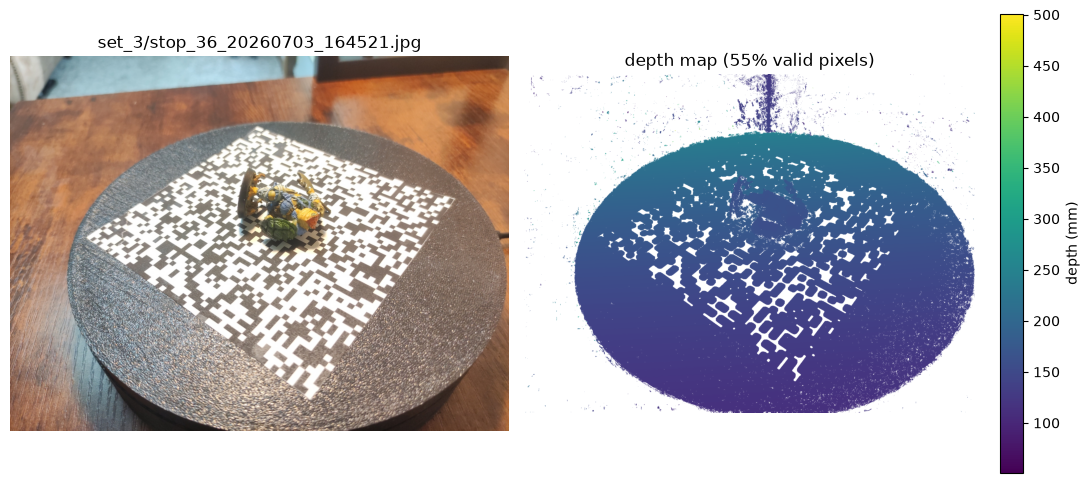

In [14]:
sample_depth_path = WORKSPACE_DIR / "stereo" / "depth_maps" / f"{undistorted_names[0]}.geometric.bin"
depth = dr.read_depth_map(sample_depth_path)
valid_frac = np.count_nonzero(depth) / depth.size

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(str(WORKSPACE_DIR / "images" / undistorted_names[0])), cv2.COLOR_BGR2RGB))
axes[0].set_title(undistorted_names[0]); axes[0].axis("off")
masked = np.ma.masked_where(depth == 0, depth)
im = axes[1].imshow(masked, cmap="viridis")
axes[1].set_title(f"depth map ({valid_frac:.0%} valid pixels)"); axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="depth (mm)", fraction=0.046)
plt.tight_layout()
plt.show()

## Step 4 - Stereo fusion

Merge every image's depth/normal maps into one dense, coloured point cloud.

In [15]:
t0 = time.time()
fused = dr.run_stereo_fusion(
    WORKSPACE_DIR, FUSED_DIR,
    min_num_pixels=FUSION_MIN_NUM_PIXELS,
    max_reproj_error=FUSION_MAX_REPROJ_ERROR,
    max_depth_error=FUSION_MAX_DEPTH_ERROR,
)
print(f"stereo_fusion elapsed: {time.time()-t0:.1f}s")
print(f"fused points: {fused.num_points3D()}")

points, colors = dr.points_and_colors(fused)
print("bounding box min/max (mm):", points.min(axis=0), points.max(axis=0))

I20260707 10:08:35.162648 129563893821888 fusion.cc:79] --- StereoFusion::Options ---
I20260707 10:08:35.162681 129563893821888 fusion.cc:80] mask_path: ""
I20260707 10:08:35.162752 129563893821888 fusion.cc:81] max_image_size: -1
I20260707 10:08:35.162756 129563893821888 fusion.cc:82] min_num_pixels: 5
I20260707 10:08:35.162757 129563893821888 fusion.cc:83] max_num_pixels: 10000
I20260707 10:08:35.162758 129563893821888 fusion.cc:84] max_traversal_depth: 100
I20260707 10:08:35.162759 129563893821888 fusion.cc:85] max_reproj_error: 2
I20260707 10:08:35.162768 129563893821888 fusion.cc:86] max_depth_error: 0.01
I20260707 10:08:35.162770 129563893821888 fusion.cc:87] max_normal_error: 10
I20260707 10:08:35.162772 129563893821888 fusion.cc:88] check_num_images: 50
I20260707 10:08:35.162773 129563893821888 fusion.cc:89] use_cache: 0
I20260707 10:08:35.162774 129563893821888 fusion.cc:90] cache_size: 32
I20260707 10:08:35.162776 129563893821888 fusion.cc:93] bbox_min: -3.40282e+38 -3.40282e

I20260707 10:08:48.840151 129563893821888 timer.cc:90] Elapsed time: 0.217 [minutes]
I20260707 10:08:48.840623 129563893821888 fusion.cc:179] Reading configuration...
I20260707 10:08:49.240904 129563893821888 fusion.cc:247] Starting fusion with 20 threads
I20260707 10:08:49.241944 129563893821888 fusion.cc:283] Fusing image [1/32] with index 0
I20260707 10:08:51.261708 129563893821888 fusion.cc:310]  in 2.020s (335827 points)
I20260707 10:08:51.261757 129563893821888 fusion.cc:283] Fusing image [2/32] with index 1
I20260707 10:08:51.843755 129563893821888 fusion.cc:310]  in 0.582s (426012 points)
I20260707 10:08:51.843801 129563893821888 fusion.cc:283] Fusing image [3/32] with index 2
I20260707 10:08:52.397064 129563893821888 fusion.cc:310]  in 0.553s (506302 points)
I20260707 10:08:52.397113 129563893821888 fusion.cc:283] Fusing image [4/32] with index 3
I20260707 10:08:52.927361 129563893821888 fusion.cc:310]  in 0.530s (572976 points)
I20260707 10:08:52.927412 129563893821888 fusion

stereo_fusion elapsed: 45.2s
fused points: 1219180
bounding box min/max (mm): [-224.09185791 -200.25404358  -83.20968628] [164.38040161 193.9559021   89.84890747]


## Raw dense point cloud

Coloured by the photographs' own pixel values. Subsampled for plotting only - the full cloud is what gets written to disk.

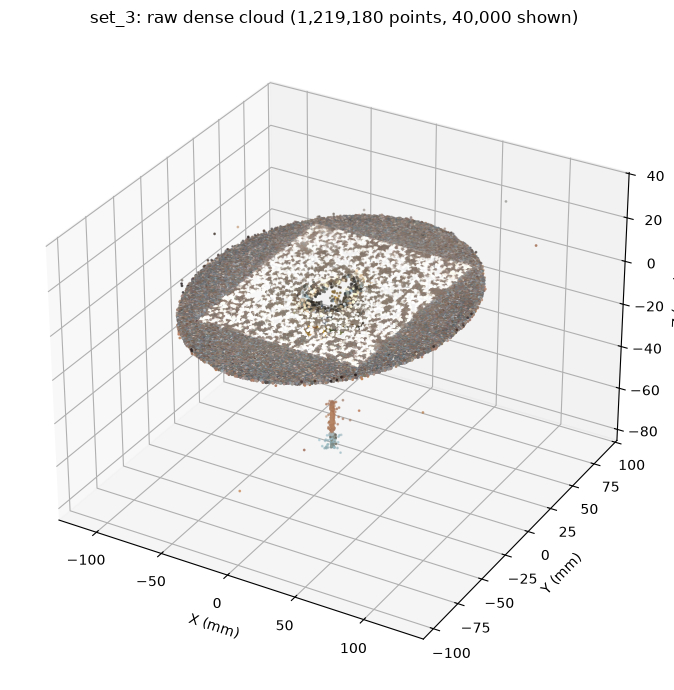

In [16]:
plot_sample = np.random.default_rng(0).choice(len(points), size=min(40_000, len(points)), replace=False)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    points[plot_sample, 0], points[plot_sample, 1], points[plot_sample, 2],
    c=colors[plot_sample] / 255.0, s=1,
)
ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
ax.set_title(f"{SET_NAME}: raw dense cloud ({len(points):,} points, {len(plot_sample):,} shown)")
plt.tight_layout()
plt.show()

## Step 5 - Region of interest and achieved density

Exhaustive real&harr;real stereo also reconstructs the calibration plate and any well-textured
background, not just the artefact - restrict to a rough sphere around the world origin (where the
plate is centred) before computing density, or the plate's own flat surface would dominate the
count. Surface area is approximated as the ROI points' axis-aligned bounding-box surface area
(no mesh exists yet at this stage of the pipeline).

In [17]:
roi_points, roi_colors = dr.filter_by_radius(points, colors, radius_mm=ROI_RADIUS_MM)
print(f"ROI (radius={ROI_RADIUS_MM}mm): {len(roi_points)} / {len(points)} points")

roi_area_mm2 = dr.bounding_box_surface_area_mm2(roi_points)
raw_density = len(roi_points) / roi_area_mm2
print(f"ROI bounding-box surface area: {roi_area_mm2:.0f} mm^2")
print(f"raw achieved density: {raw_density:.2f} points/mm^2")

dr.write_ply(OUT_DIR / "dense_raw.ply", roi_points, roi_colors)
print(f"wrote {OUT_DIR / 'dense_raw.ply'}")

ROI (radius=65.0mm): 399653 / 1219180 points
ROI bounding-box surface area: 70439 mm^2
raw achieved density: 5.67 points/mm^2
wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_3/dense/dense_raw.ply


## Step 6 - Downsample towards the target densities

`downsample_to_density` voxel-downsamples towards a target; if the raw cloud is already sparser
than the target (as above), it's returned unchanged - no amount of downsampling can invent points
a camera never resolved. Both target outputs are written regardless, clearly named, so downstream
steps can use whichever a given target actually needs.

In [10]:
results = []
for target in DENSITY_TARGETS_PER_MM2:
    out_points, out_colors, achieved, reached_target = dr.downsample_to_density(
        roi_points, roi_colors, target, roi_area_mm2
    )
    out_path = OUT_DIR / f"dense_{int(target)}ppmm2.ply"
    dr.write_ply(out_path, out_points, out_colors)
    results.append((target, len(out_points), achieved, reached_target, out_path))
    status = "reached" if reached_target else "NOT reached (raw cloud is already sparser than this)"
    print(f"target={target:.0f} pts/mm^2: {len(out_points):,} points, achieved={achieved:.2f} pts/mm^2 - {status}")
    print(f"  wrote {out_path}")

target=100 pts/mm^2: 423,292 points, achieved=6.07 pts/mm^2 - NOT reached (raw cloud is already sparser than this)
  wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_1/dense/dense_100ppmm2.ply


target=300 pts/mm^2: 423,292 points, achieved=6.07 pts/mm^2 - NOT reached (raw cloud is already sparser than this)
  wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_1/dense/dense_300ppmm2.ply


## Summary

In [ ]:
print(f"{SET_NAME}")
print(f"  raw fused points:        {len(points):,}")
print(f"  ROI points (r={ROI_RADIUS_MM:.0f}mm):     {len(roi_points):,}  ({raw_density:.2f} pts/mm^2 over {roi_area_mm2:.0f} mm^2)")
for target, n, achieved, reached, path in results:
    print(f"  target {target:>5.0f} pts/mm^2: {n:,} points, {achieved:.2f} pts/mm^2 achieved ({'OK' if reached else 'target unreachable with this data'})")